In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("HRDataset_v14_enriched.csv")
df.head()
df.shape
df.columns
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 38 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_Name               311 non-null    str    
 1   EmpID                       311 non-null    int64  
 2   MarriedID                   311 non-null    int64  
 3   MaritalStatusID             311 non-null    int64  
 4   GenderID                    311 non-null    int64  
 5   EmpStatusID                 311 non-null    int64  
 6   DeptID                      311 non-null    int64  
 7   PerfScoreID                 311 non-null    int64  
 8   FromDiversityJobFairID      311 non-null    int64  
 9   Salary                      311 non-null    int64  
 10  Termd                       311 non-null    int64  
 11  PositionID                  311 non-null    int64  
 12  Position                    311 non-null    str    
 13  State                       311 non-null    st

Employee_Name                   0
EmpID                           0
MarriedID                       0
MaritalStatusID                 0
GenderID                        0
EmpStatusID                     0
DeptID                          0
PerfScoreID                     0
FromDiversityJobFairID          0
Salary                          0
Termd                           0
PositionID                      0
Position                        0
State                           0
Zip                             0
DOB                             0
Sex                             0
MaritalDesc                     0
CitizenDesc                     0
HispanicLatino                  0
RaceDesc                        0
DateofHire                      0
DateofTermination             207
TermReason                      0
EmploymentStatus                0
Department                      0
ManagerName                     0
ManagerID                       8
RecruitmentSource               0
PerformanceSco

Now we will drop the columns that are usueless/unethical/redondant


In [ ]:
cols_to_drop = [
    "Employee_Name",
    "EmpID",
    "GenderID",
    "Sex",
    "MaritalDesc",
    "CitizenDesc",
    "HispanicLatino",
    "RaceDesc",
    "MaritalStatusID",
    "MarriedID",
    "PositionID",
    "Zip",
    "DateofTermination",
    "TermReason",
    "EmploymentStatus",
    "Internal_Transfer_Request",
    "EmpStatusID",
    "Feedback_RH"
]

df = df.drop(columns=cols_to_drop)

In [53]:
df.columns

Index(['DeptID', 'PerfScoreID', 'FromDiversityJobFairID', 'Salary', 'Termd',
       'Position', 'State', 'DOB', 'DateofHire', 'Department', 'ManagerName',
       'ManagerID', 'RecruitmentSource', 'PerformanceScore',
       'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount',
       'LastPerformanceReview_Date', 'DaysLateLast30', 'Absences',
       'Feedback_RH'],
      dtype='str')

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


=== TARGET DISTRIBUTION ===
Termd
0    207
1    104
Name: count, dtype: int64
Termd
0    0.665595
1    0.334405
Name: proportion, dtype: float64


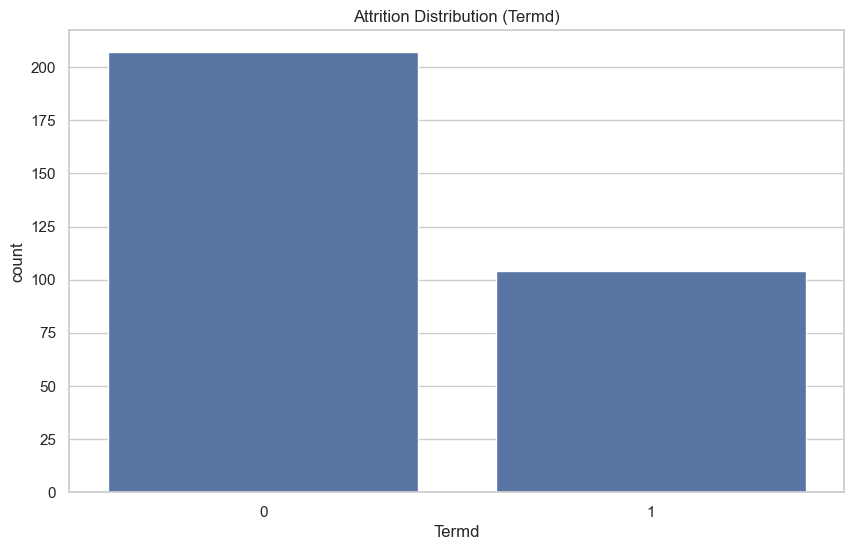

In [55]:
print("\n=== TARGET DISTRIBUTION ===")
print(df["Termd"].value_counts())
print(df["Termd"].value_counts(normalize=True))

plt.figure()
sns.countplot(data=df, x="Termd")
plt.title("Attrition Distribution (Termd)")
plt.show()



=== NUMERIC MEANS BY ATTRITION ===
Termd                              0             1
Salary                  70694.033816  65690.076923
ManagerID                  13.351759     16.903846
Absences                    9.830918     11.048077
DeptID                      4.560386      4.711538
EngagementSurvey            4.119807      4.090481
EmpSatisfaction             3.893720      3.884615
PerfScoreID                 3.014493      2.903846
SpecialProjectsCount        1.463768      0.730769
DaysLateLast30              0.289855      0.663462
FromDiversityJobFairID      0.062802      0.153846


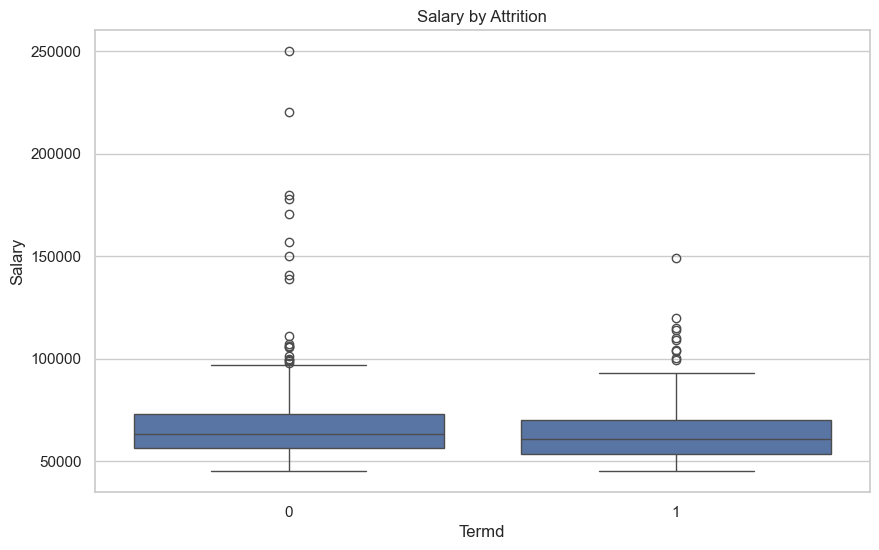

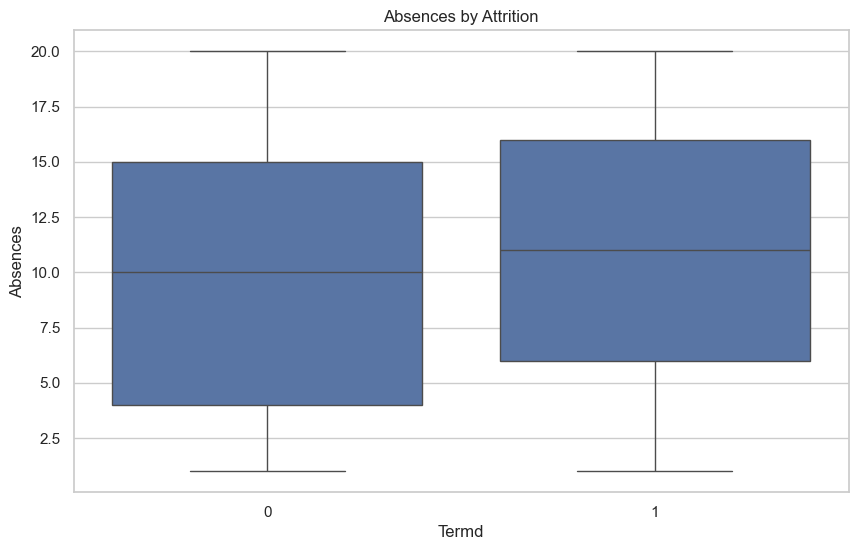

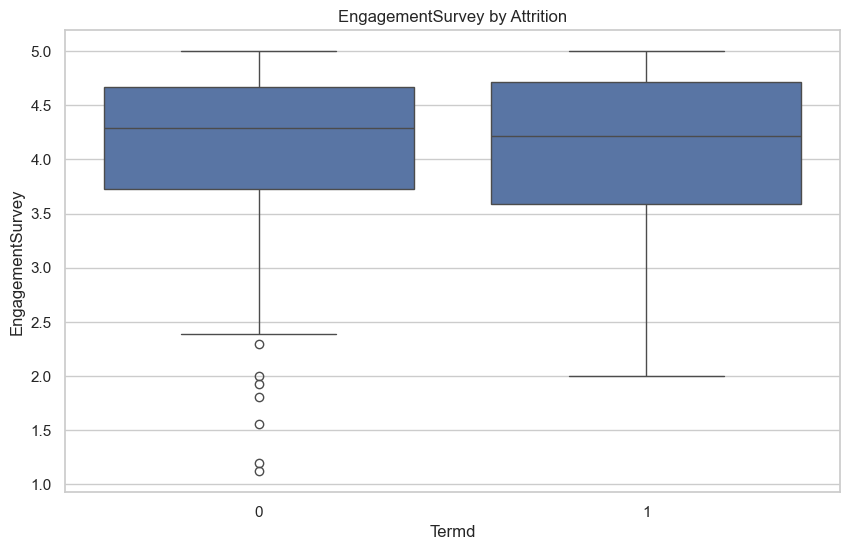

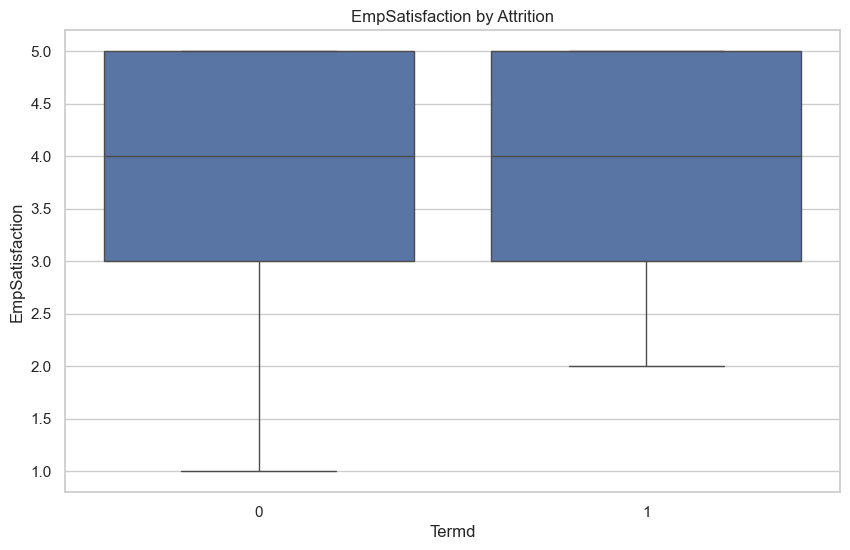

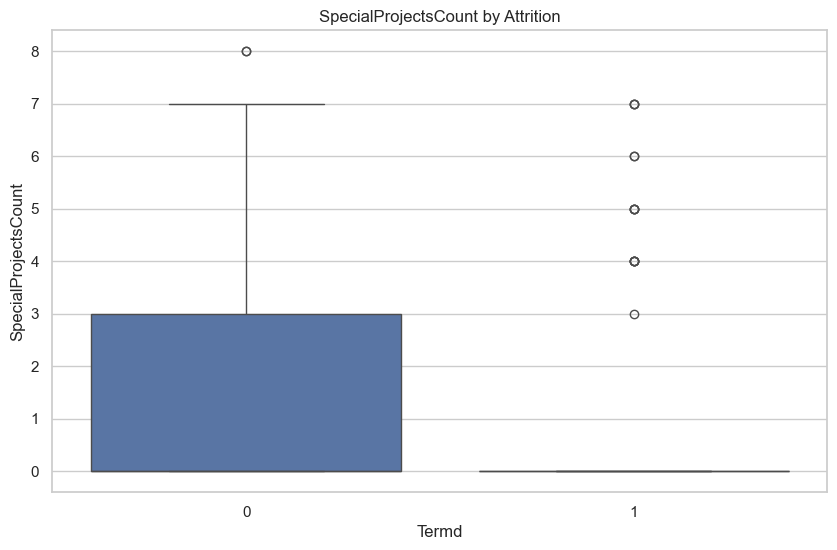

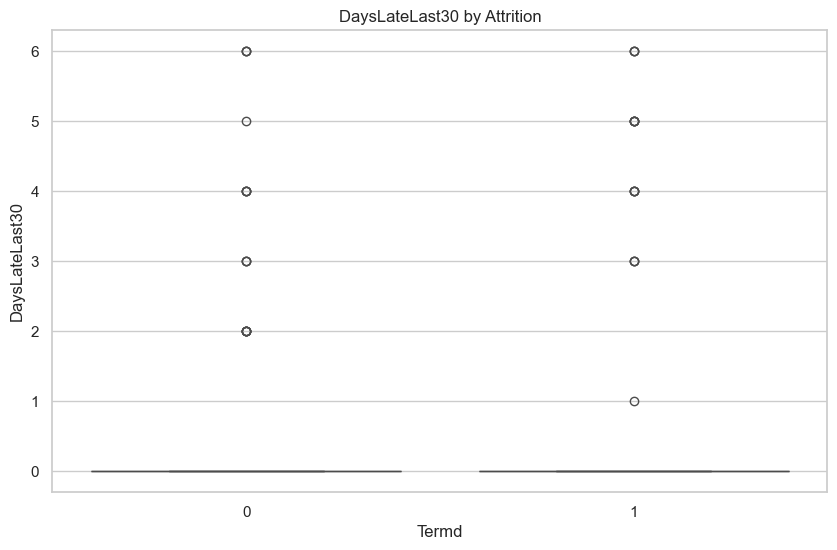

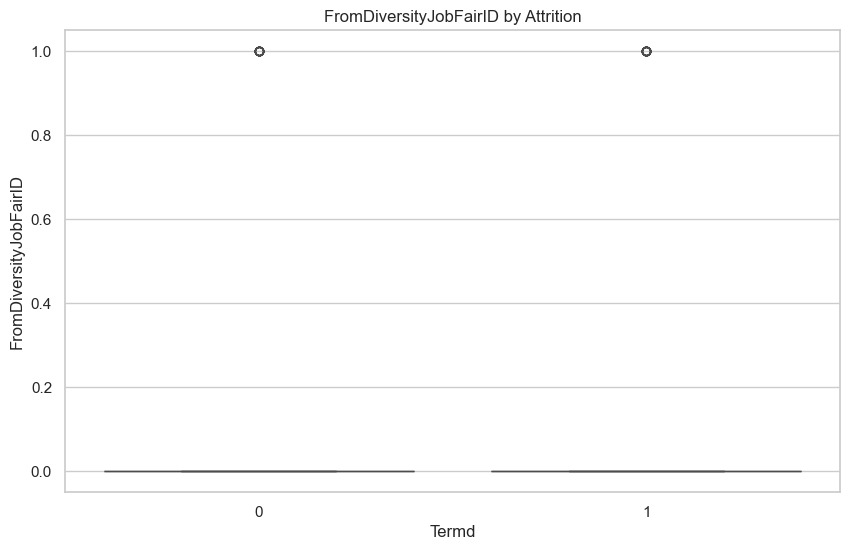

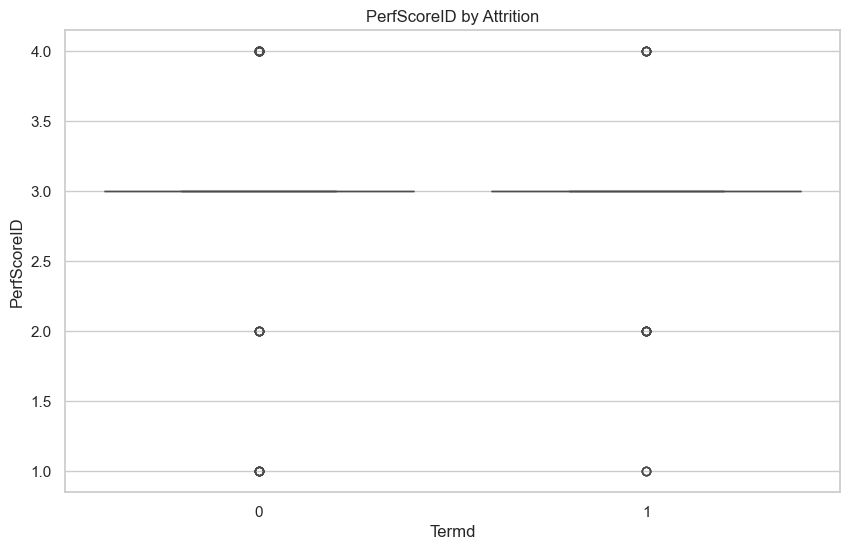

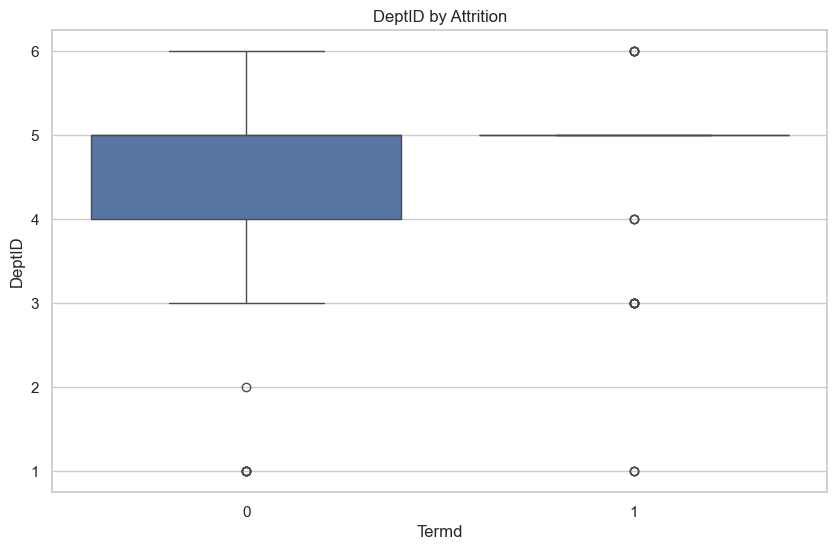

In [56]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != "Termd"]

print("\n=== NUMERIC MEANS BY ATTRITION ===")
print(df.groupby("Termd")[numeric_cols].mean().T.sort_values(by=1, ascending=False))

important_numeric = [
    col for col in [
        "Salary",
        "Absences",
        "EngagementSurvey",
        "EmpSatisfaction",
        "SpecialProjectsCount",
        "DaysLateLast30",
        "FromDiversityJobFairID",
        "PerfScoreID",
        "DeptID"
    ] if col in df.columns
]

for col in important_numeric:
    plt.figure()
    sns.boxplot(data=df, x="Termd", y=col)
    plt.title(f"{col} by Attrition")
    plt.show()

C:\Users\dridr\AppData\Local\Temp\ipykernel_37656\1294098253.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.tolist()


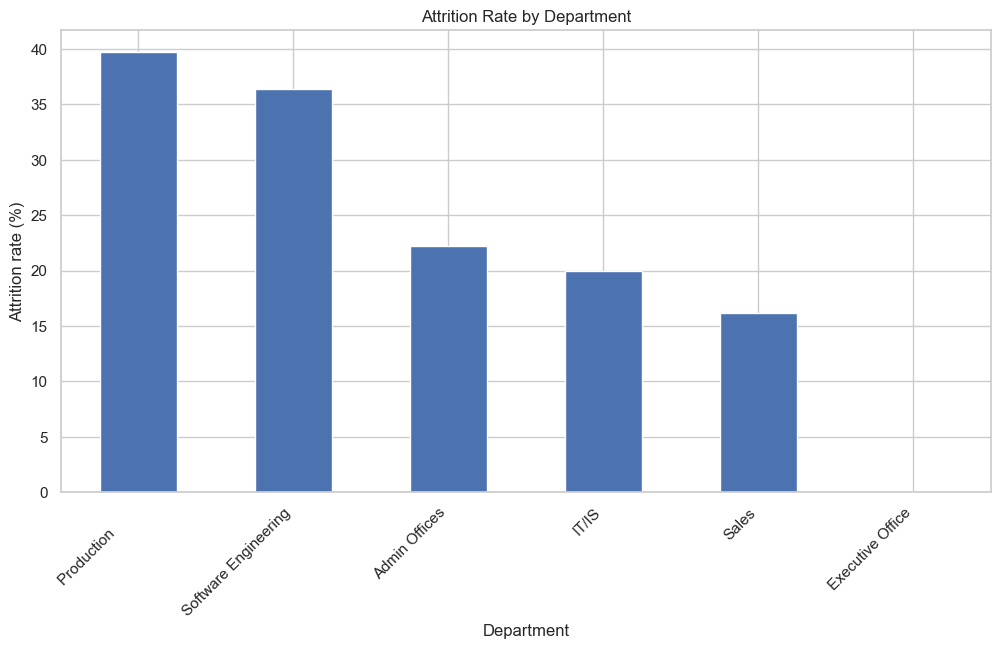

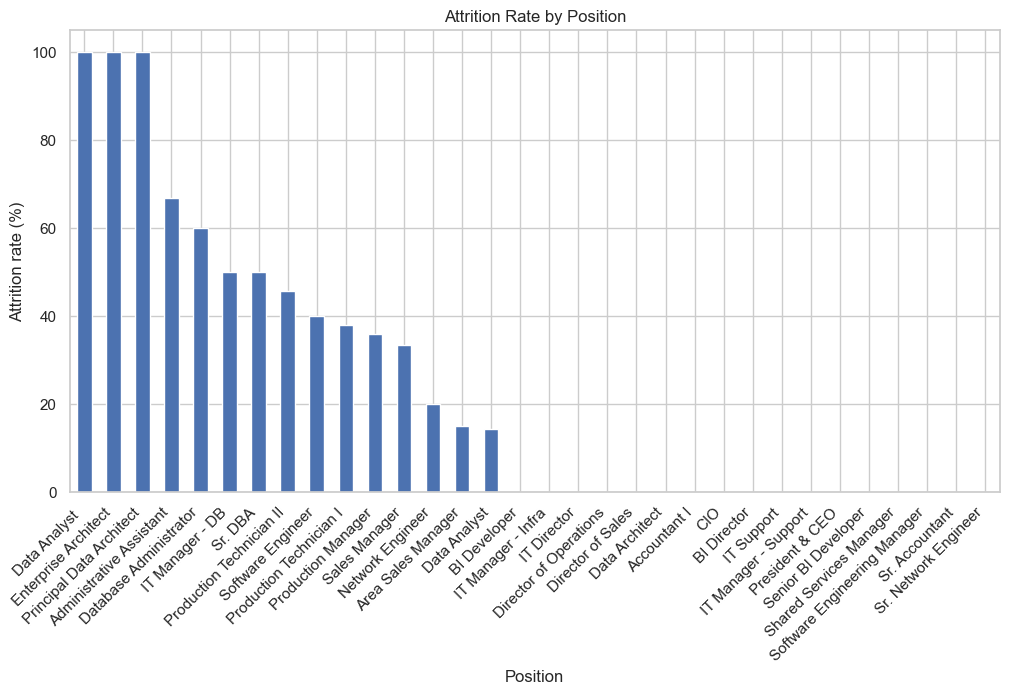

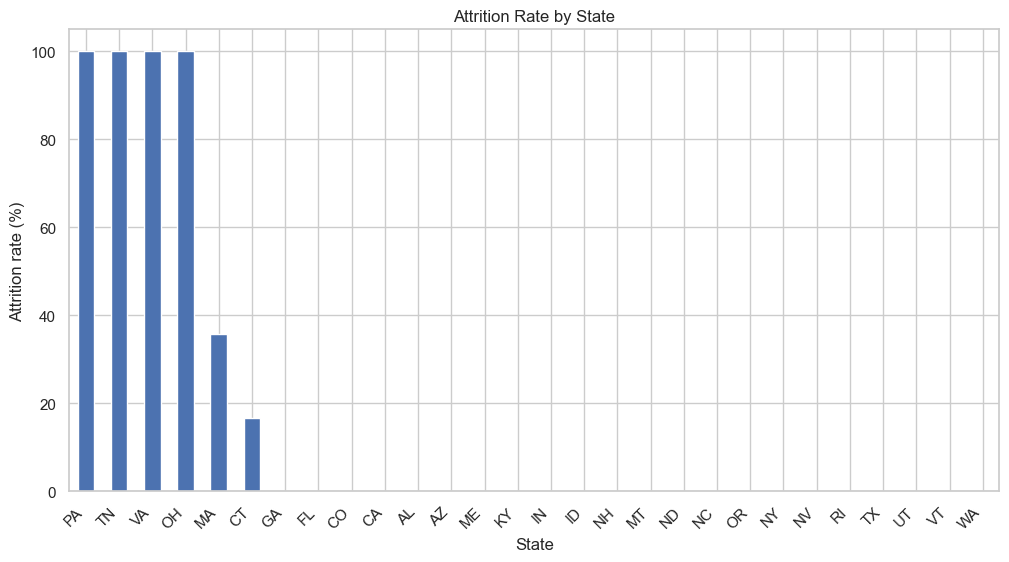

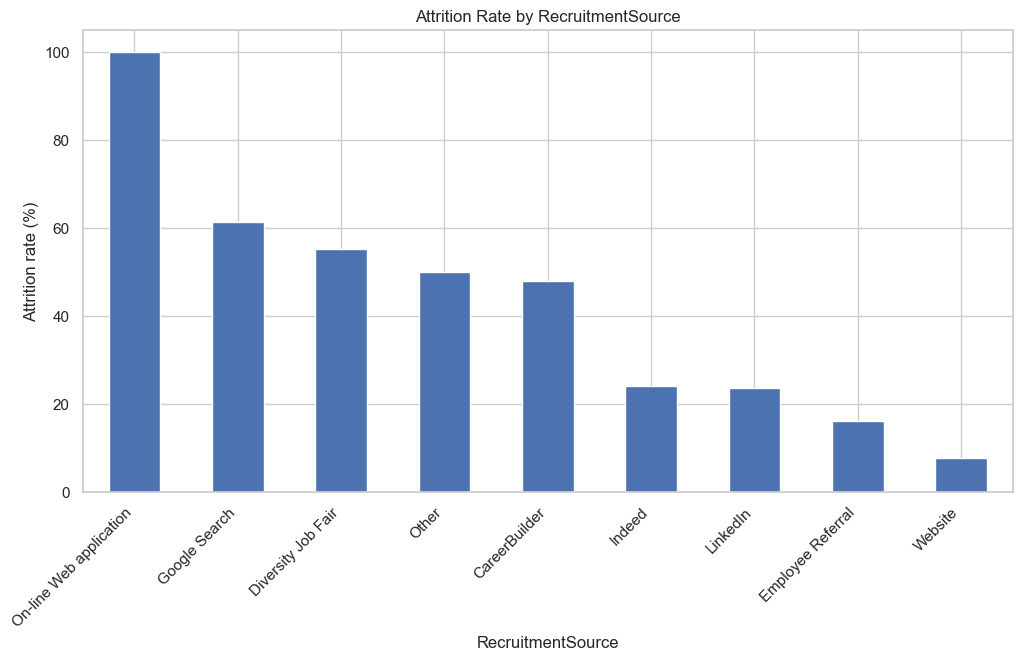

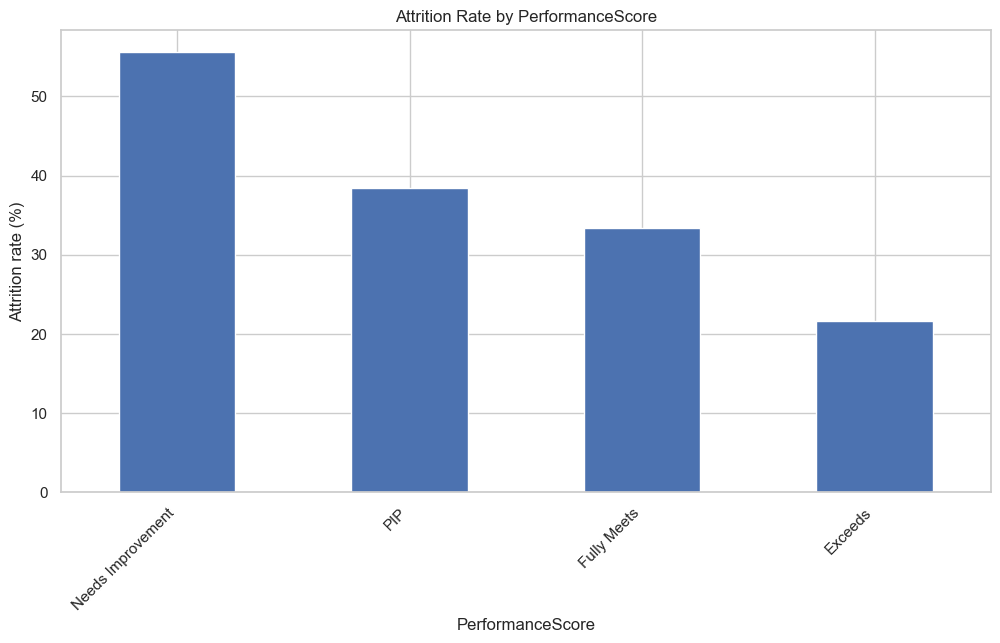

In [57]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()

important_cats = [
    col for col in [
        "Department",
        "Position",
        "State",
        "RecruitmentSource",
        "PerformanceScore"
    ] if col in categorical_cols
]

for col in important_cats:
    plt.figure(figsize=(12, 6))
    attrition_rate = pd.crosstab(df[col], df["Termd"], normalize="index") * 100
    
    if 1 in attrition_rate.columns:
        attrition_rate = attrition_rate.sort_values(by=1, ascending=False)
        attrition_rate[1].plot(kind="bar")
        plt.title(f"Attrition Rate by {col}")
        plt.ylabel("Attrition rate (%)")
        plt.xticks(rotation=45, ha="right")
        plt.show()


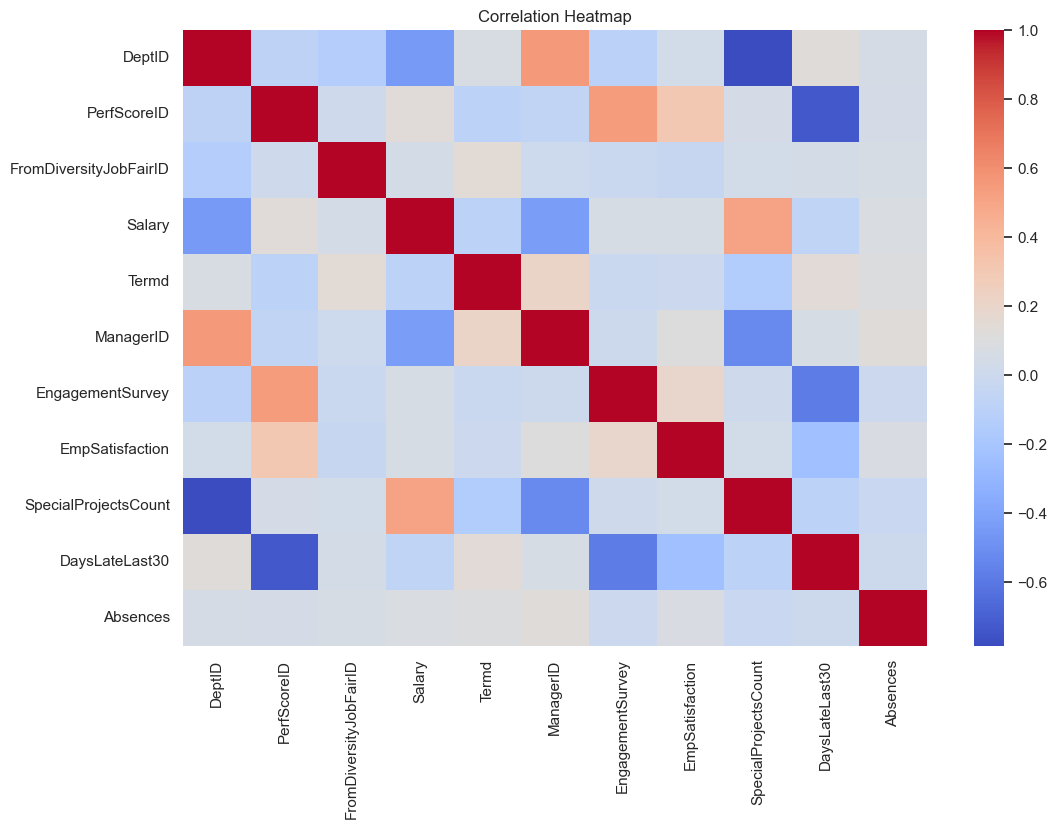

In [58]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [59]:
model_df = df.copy()

# Optional date engineering
date_cols = ["DOB", "DateofHire", "LastPerformanceReview_Date"]
for col in date_cols:
    if col in model_df.columns:
        model_df[col] = pd.to_datetime(model_df[col], errors="coerce")

if "DOB" in model_df.columns:
    model_df["Age"] = 2026 - model_df["DOB"].dt.year
if "DateofHire" in model_df.columns:
    model_df["YearsAtCompany"] = 2026 - model_df["DateofHire"].dt.year
if "LastPerformanceReview_Date" in model_df.columns:
    model_df["ReviewYear"] = model_df["LastPerformanceReview_Date"].dt.year

model_df = model_df.drop(columns=[col for col in date_cols if col in model_df.columns])

# Fill missing object values
for col in model_df.select_dtypes(include="object").columns:
    model_df[col] = model_df[col].fillna("Unknown")

# Fill missing numeric values
for col in model_df.select_dtypes(include=np.number).columns:
    model_df[col] = model_df[col].fillna(model_df[col].median())

# One-hot encoding
model_df = pd.get_dummies(model_df, drop_first=True)

X = model_df.drop("Termd", axis=1)
y = model_df["Termd"]

C:\Users\dridr\AppData\Local\Temp\ipykernel_37656\326601244.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  model_df[col] = pd.to_datetime(model_df[col], errors="coerce")
C:\Users\dridr\AppData\Local\Temp\ipykernel_37656\326601244.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in model_df.select_dtypes(include="object").columns:


In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

print("\n=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred))


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      1.00      1.00        21

    accuracy                           1.00        63
   macro avg       1.00      1.00      1.00        63
weighted avg       1.00      1.00      1.00        63


=== CONFUSION MATRIX ===
[[42  0]
 [ 0 21]]



=== TOP 15 FACTORS LINKED TO ATTRITION ===
ReviewYear                                                                                                                                                                                                                               0.411093
Feedback_RH_Unknown                                                                                                                                                                                                                      0.120142
YearsAtCompany                                                                                                                                                                                                                           0.090534
ManagerID                                                                                                                                                                                                                             

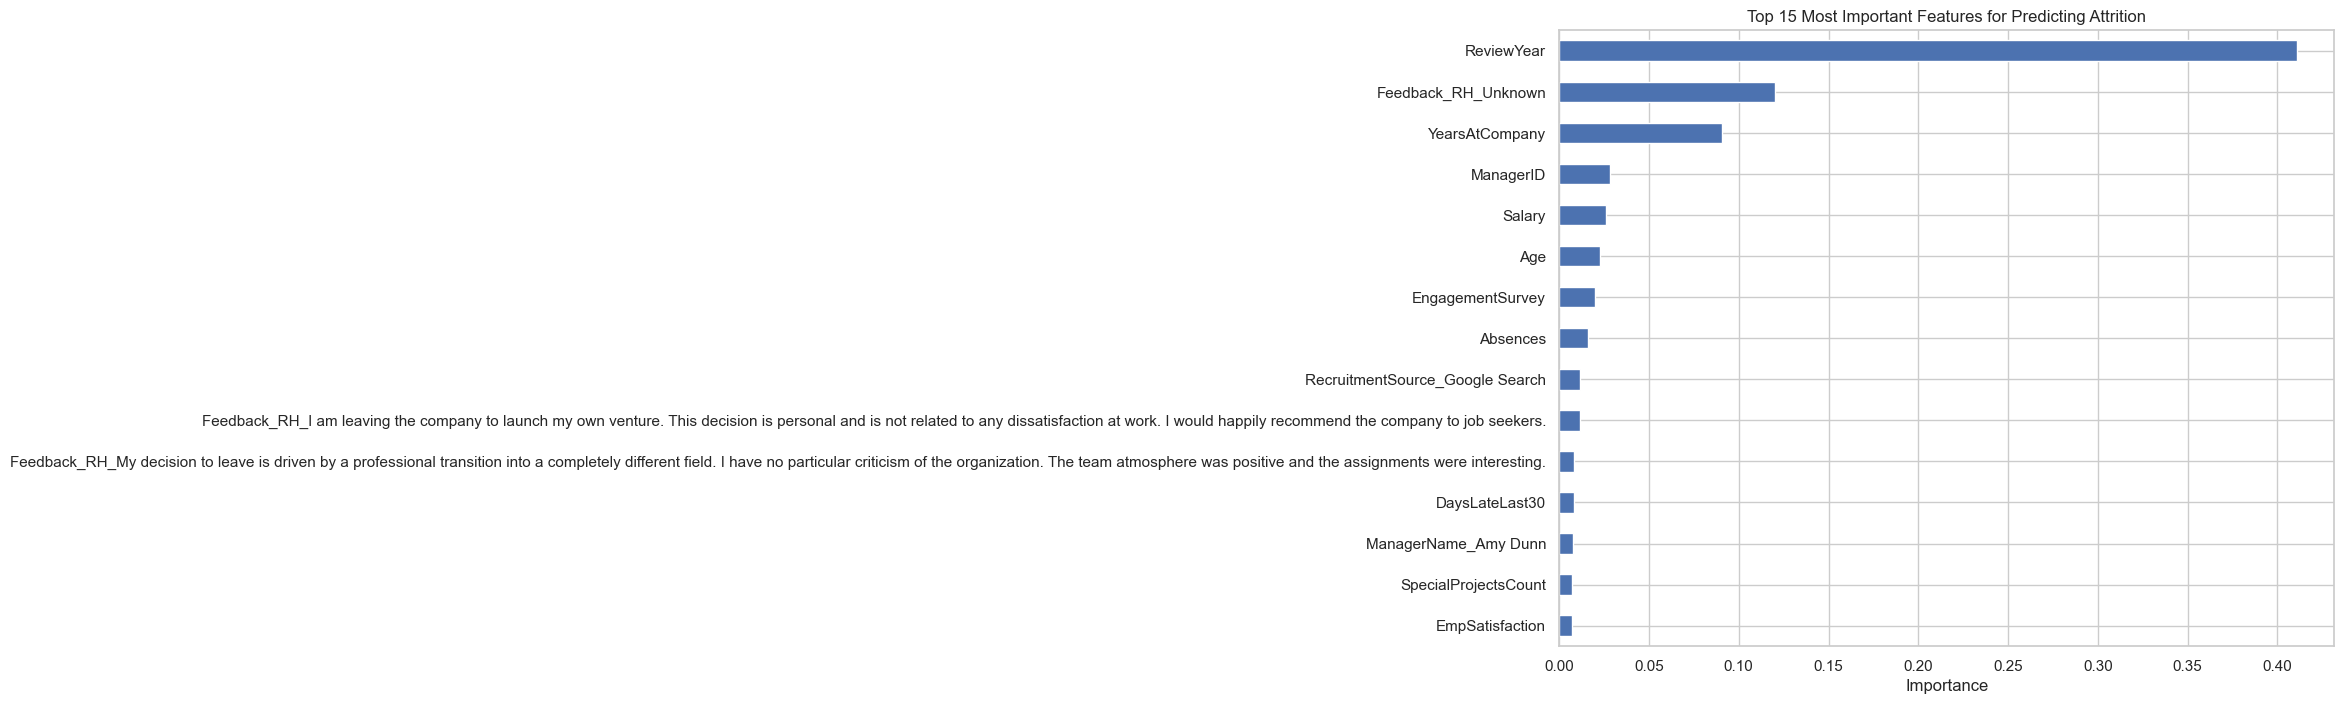

In [61]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print("\n=== TOP 15 FACTORS LINKED TO ATTRITION ===")
print(feature_importance.head(15))

plt.figure(figsize=(10, 8))
feature_importance.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Most Important Features for Predicting Attrition")
plt.xlabel("Importance")
plt.show()